# AMR Drug Repurposing — 03: Publication-Ready Figures

Re-generates all figures with journal-quality settings: 300 DPI, Arial/Helvetica fonts, Nature-style colour palette, proper axis labels, and scalable vector exports (SVG + PNG).

## Paths

In [1]:
from pathlib import Path
import os

PROJECT_ROOT = Path(__file__).resolve().parents[1] if '__file__' in dir() else Path.cwd().parent
# When running from notebooks/ dir, parent is the project root
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = Path.cwd()

DATA_DIR  = PROJECT_ROOT / 'data'
CKPT_DIR  = PROJECT_ROOT / 'checkpoints'
FIG_DIR   = PROJECT_ROOT / 'figures'

for d in [DATA_DIR, CKPT_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_DIR     : {DATA_DIR}")
print(f"CKPT_DIR     : {CKPT_DIR}")
print(f"FIG_DIR      : {FIG_DIR}")

PROJECT_ROOT : /Users/jubayer/Projects/amr_drug_repurposing
DATA_DIR     : /Users/jubayer/Projects/amr_drug_repurposing/data
CKPT_DIR     : /Users/jubayer/Projects/amr_drug_repurposing/checkpoints
FIG_DIR      : /Users/jubayer/Projects/amr_drug_repurposing/figures


## Imports & global matplotlib style

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from sklearn.metrics import (roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve,
                              confusion_matrix)

import warnings
warnings.filterwarnings('ignore')

# ── Publication-quality matplotlib defaults 
plt.rcParams.update({
    # Font
    'font.family':          'sans-serif',
    'font.sans-serif':      ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size':            9,
    'axes.titlesize':       10,
    'axes.labelsize':       9,
    'xtick.labelsize':      8,
    'ytick.labelsize':      8,
    'legend.fontsize':      8,
    'legend.title_fontsize':8,
    # Lines
    'axes.linewidth':       0.8,
    'xtick.major.width':    0.8,
    'ytick.major.width':    0.8,
    'lines.linewidth':      1.5,
    # Layout
    'axes.spines.top':      False,
    'axes.spines.right':    False,
    'figure.dpi':           150,
    'savefig.dpi':          300,
    'savefig.bbox':         'tight',
    'savefig.transparent':  False,
    # Grid
    'axes.grid':            False,
})

# Colour palette (Nature-inspired)
C = {
    'active':    '#2166AC',   # blue
    'inactive':  '#B2182B',   # red
    'mlp':       '#1B7837',   # dark green
    'rf':        '#762A83',   # purple
    'ensemble':  '#D6604D',   # salmon
    'neutral':   '#878787',   # grey
    'highlight': '#F4A582',   # light salmon
}

DPI = 300
FMT = ['png', 'svg']

def save_fig(fig, name):
    for fmt in FMT:
        out = FIG_DIR / f"{name}.{fmt}"
        fig.savefig(out, dpi=DPI, bbox_inches='tight')
    print(f"Saved: {name}.png / .svg")

print("Matplotlib style configured.")

Matplotlib style configured.


## Load saved artefacts

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.ensemble import RandomForestClassifier
import pickle, os, time
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('mps' if torch.backends.mps.is_available()
                       else 'cuda' if torch.cuda.is_available() else 'cpu')

X = np.load(DATA_DIR / 'X_ecfp.npy')
y = np.load(DATA_DIR / 'y_labels.npy')
df_clean   = pd.read_csv(DATA_DIR / 'eskape_clean.csv')
df_results = pd.read_csv(DATA_DIR / 'repurposing_candidates.csv')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Re-train RF quickly (deterministic — matches modeling notebook)
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=2,
                             class_weight='balanced', n_jobs=-1, random_state=SEED)
rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:, 1]

# Load MLP
class FingerprintDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

class AntibacterialMLP(nn.Module):
    def __init__(self, input_dim=2048, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(1024, 512),       nn.BatchNorm1d(512),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256),        nn.BatchNorm1d(256),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),        nn.BatchNorm1d(128),  nn.ReLU(), nn.Dropout(dropout * 0.5),
            nn.Linear(128, 1),
        )
    def forward(self, x): return self.net(x).squeeze(-1)

model = AntibacterialMLP().to(device)
ckpt  = torch.load(CKPT_DIR / 'best_mlp.pt', map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.eval()

test_loader = DataLoader(FingerprintDataset(X_test, y_test), batch_size=512, shuffle=False)
all_prob = []
with torch.no_grad():
    for xb, _ in test_loader:
        logits = model(xb.to(device)).cpu().numpy()
        all_prob.extend(1 / (1 + np.exp(-logits)))

mlp_prob = np.array(all_prob)
mlp_pred = (mlp_prob >= 0.5).astype(int)

mlp_roc = roc_auc_score(y_test, mlp_prob)
mlp_prc = average_precision_score(y_test, mlp_prob)
rf_roc  = roc_auc_score(y_test, rf_prob)
rf_prc  = average_precision_score(y_test, rf_prob)

print(f"MLP  ROC-AUC: {mlp_roc:.4f}  PRC-AUC: {mlp_prc:.4f}")
print(f"RF   ROC-AUC: {rf_roc:.4f}  PRC-AUC: {rf_prc:.4f}")

MLP  ROC-AUC: 0.9131  PRC-AUC: 0.8891
RF   ROC-AUC: 0.9162  PRC-AUC: 0.8917


## Figure 1 — Exploratory Data Analysis

Saved: fig1_eda.png / .svg


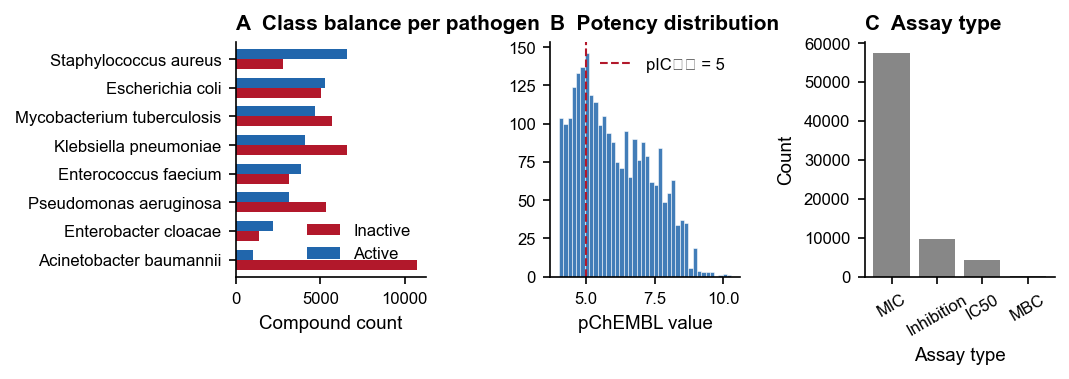

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.6))

# Panel A: class balance per organism
org_counts = (df_clean.groupby(['target_organism', 'active'])
                       .size().unstack(fill_value=0)
                       .rename(columns={0:'Inactive', 1:'Active'}))
org_counts.index = [' '.join(x.split()[:2]) for x in org_counts.index]
org_counts.sort_values('Active', ascending=True).plot(
    kind='barh', ax=axes[0], color=[C['inactive'], C['active']], width=0.7, edgecolor='none'
)
axes[0].set_xlabel('Compound count')
axes[0].set_title('A  Class balance per pathogen', loc='left', fontweight='bold')
axes[0].legend(frameon=False)

# Panel B: pChEMBL or log activity
pchem = df_clean['pchembl_value'].dropna().astype(float)
if len(pchem) > 100:
    axes[1].hist(pchem, bins=40, color=C['active'], edgecolor='white', linewidth=0.3, alpha=0.85)
    axes[1].axvline(5, color=C['inactive'], ls='--', lw=1, label='pIC₅₀ = 5')
    axes[1].set_xlabel('pChEMBL value')
    axes[1].set_title('B  Potency distribution', loc='left', fontweight='bold')
    axes[1].legend(frameon=False)
else:
    log_vals = np.log10(df_clean['value_uM'].clip(1e-3, 1e5))
    axes[1].hist(log_vals, bins=40, color=C['active'], edgecolor='white', linewidth=0.3, alpha=0.85)
    axes[1].set_xlabel('log₁₀(activity value, µM)')
    axes[1].set_title('B  Activity distribution', loc='left', fontweight='bold')

# Panel C: assay type distribution
stype = df_clean['standard_type'].value_counts().head(6)
axes[2].bar(stype.index, stype.values, color=C['neutral'], edgecolor='none')
axes[2].set_xlabel('Assay type')
axes[2].set_ylabel('Count')
axes[2].set_title('C  Assay type', loc='left', fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout(w_pad=2)
save_fig(fig, 'fig1_eda')
plt.show()

## Figure 2 — Model evaluation (ROC + PR + confusion matrix)

Saved: fig2_evaluation.png / .svg


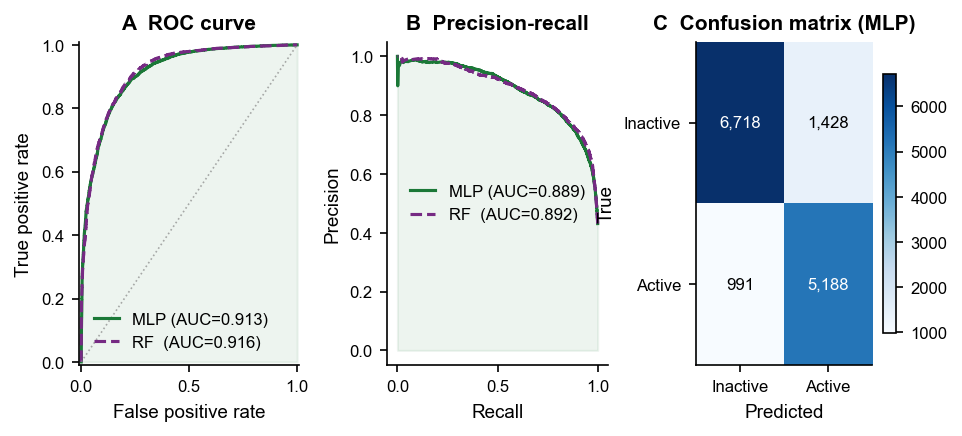

In [5]:
fig = plt.figure(figsize=(7.2, 2.8))
gs  = fig.add_gridspec(1, 3, wspace=0.4)
ax1, ax2, ax3 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

# Panel A: ROC
fpr_m, tpr_m, _ = roc_curve(y_test, mlp_prob)
fpr_r, tpr_r, _ = roc_curve(y_test, rf_prob)
ax1.plot(fpr_m, tpr_m, color=C['mlp'], lw=1.5, label=f'MLP (AUC={mlp_roc:.3f})')
ax1.plot(fpr_r, tpr_r, color=C['rf'],  lw=1.5, ls='--', label=f'RF  (AUC={rf_roc:.3f})')
ax1.plot([0,1],[0,1], color=C['neutral'], lw=0.8, ls=':', alpha=0.7)
ax1.fill_between(fpr_m, tpr_m, alpha=0.08, color=C['mlp'])
ax1.set(xlabel='False positive rate', ylabel='True positive rate',
        title='A  ROC curve', xlim=(-0.01,1.01), ylim=(-0.01,1.01))
ax1.legend(frameon=False, handlelength=1.5)
ax1.title.set_fontweight('bold')

# Panel B: PR
prec_m, rec_m, _ = precision_recall_curve(y_test, mlp_prob)
prec_r, rec_r, _ = precision_recall_curve(y_test, rf_prob)
ax2.plot(rec_m, prec_m, color=C['mlp'], lw=1.5, label=f'MLP (AUC={mlp_prc:.3f})')
ax2.plot(rec_r, prec_r, color=C['rf'],  lw=1.5, ls='--', label=f'RF  (AUC={rf_prc:.3f})')
ax2.fill_between(rec_m, prec_m, alpha=0.08, color=C['mlp'])
ax2.set(xlabel='Recall', ylabel='Precision', title='B  Precision-recall')
ax2.legend(frameon=False, handlelength=1.5)
ax2.title.set_fontweight('bold')

# Panel C: Confusion matrix (MLP)
cm = confusion_matrix(y_test, mlp_pred)
im = ax3.imshow(cm, cmap='Blues', aspect='auto')
ax3.set_xticks([0,1]); ax3.set_yticks([0,1])
ax3.set_xticklabels(['Inactive','Active']); ax3.set_yticklabels(['Inactive','Active'])
ax3.set_xlabel('Predicted'); ax3.set_ylabel('True')
ax3.set_title('C  Confusion matrix (MLP)', fontweight='bold')
for i in range(2):
    for j in range(2):
        ax3.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                 color='white' if cm[i,j] > cm.max()*0.5 else 'black', fontsize=8)
fig.colorbar(im, ax=ax3, shrink=0.8)

plt.tight_layout()
save_fig(fig, 'fig2_evaluation')
plt.show()

## Figure 3 — Repurposing candidates

Saved: fig3_repurposing.png / .svg


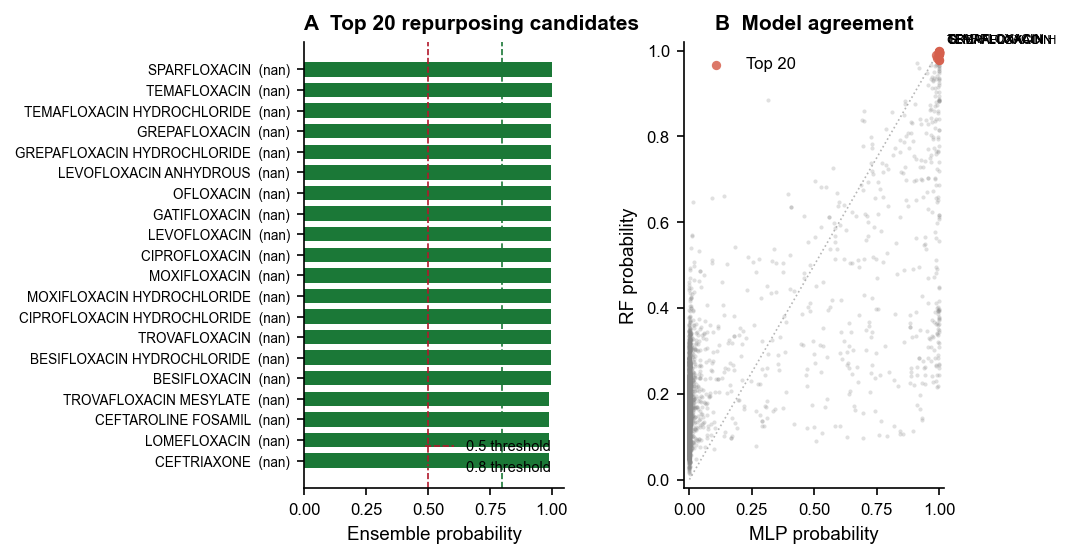

In [6]:
top20 = df_results.head(20).copy()

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.8))

# Panel A: horizontal bar chart
scores = top20['prob_ensemble'].values
colors = [C['mlp'] if s >= 0.8 else C['ensemble'] if s >= 0.6 else C['neutral'] for s in scores]
axes[0].barh(range(len(top20)), scores, color=colors, edgecolor='none', height=0.7)
axes[0].set_yticks(range(len(top20)))
labels = [f"{row['drug_name']}  ({str(row['indication'])[:20]})"
          for _, row in top20.iterrows()]
axes[0].set_yticklabels(labels, fontsize=6.5)
axes[0].axvline(0.5, color=C['inactive'],  ls='--', lw=0.8, label='0.5 threshold')
axes[0].axvline(0.8, color=C['mlp'],       ls='--', lw=0.8, label='0.8 threshold')
axes[0].set_xlabel('Ensemble probability')
axes[0].set_title('A  Top 20 repurposing candidates', loc='left', fontweight='bold')
axes[0].invert_yaxis()
axes[0].set_xlim(0, 1.05)
axes[0].legend(frameon=False, fontsize=7, loc='lower right')

# Panel B: MLP vs RF scatter
axes[1].scatter(df_results['prob_mlp'], df_results['prob_rf'],
                s=4, alpha=0.25, color=C['neutral'], linewidths=0)
axes[1].scatter(top20['prob_mlp'], top20['prob_rf'],
                s=20, alpha=0.85, color=C['ensemble'], label='Top 20', zorder=5, linewidths=0)
for _, row in top20.head(5).iterrows():
    axes[1].annotate(str(row['drug_name'])[:14],
                     (row['prob_mlp'], row['prob_rf']),
                     fontsize=6, xytext=(4,4), textcoords='offset points')
axes[1].plot([0,1],[0,1], color=C['neutral'], lw=0.8, ls=':', alpha=0.6)
axes[1].set(xlabel='MLP probability', ylabel='RF probability',
            title='B  Model agreement', xlim=(-0.02,1.02), ylim=(-0.02,1.02))
axes[1].legend(frameon=False)
axes[1].title.set_fontweight('bold')

plt.tight_layout(w_pad=3)
save_fig(fig, 'fig3_repurposing')
plt.show()

## Figure 4 — Top 5 candidate structures

Saved fig4_top5_structures.png


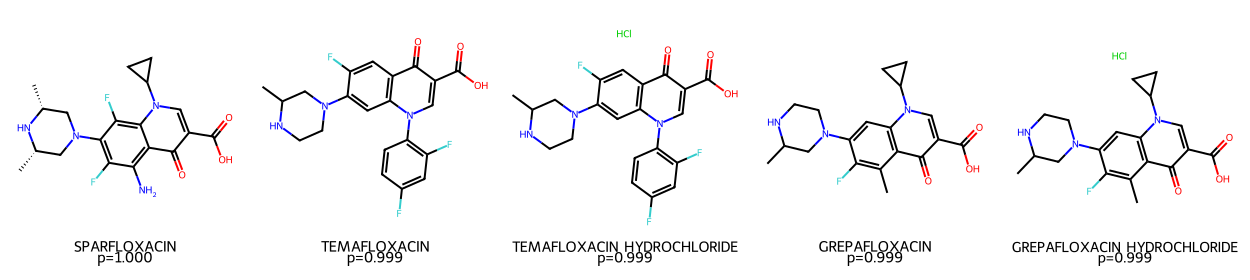

In [7]:
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display, Image as IPImage
import io
from PIL import Image

top5 = df_results.head(5)
mols = []
for _, row in top5.iterrows():
    m = Chem.MolFromSmiles(row['smiles'])
    if m:
        mols.append((m, row['drug_name'], row['prob_ensemble']))

if mols:
    n_cols = len(mols)
    drawer = rdMolDraw2D.MolDraw2DSVG(n_cols * 250, 280, 250, 280)
    drawer.drawOptions().addStereoAnnotation = True
    drawer.drawOptions().padding = 0.15
    
    img = Draw.MolsToGridImage(
        [m for m,_,_ in mols], molsPerRow=n_cols,
        subImgSize=(250, 280), useSVG=False,
        legends=[f"{name}\np={p:.3f}" for _,name,p in mols]
    )
    if hasattr(img, 'save'):
        img.save(str(FIG_DIR / 'fig4_top5_structures.png'), dpi=300)
        # Also save SVG via individual molecules
    print(f"Saved fig4_top5_structures.png")
    display(img)
else:
    print("No valid molecules to draw.")

## Figure 5 — SHAP feature importance

Computing SHAP values...


 99%|===================| 994/1000 [02:35<00:00]        

Saved: fig5_shap.png / .svg


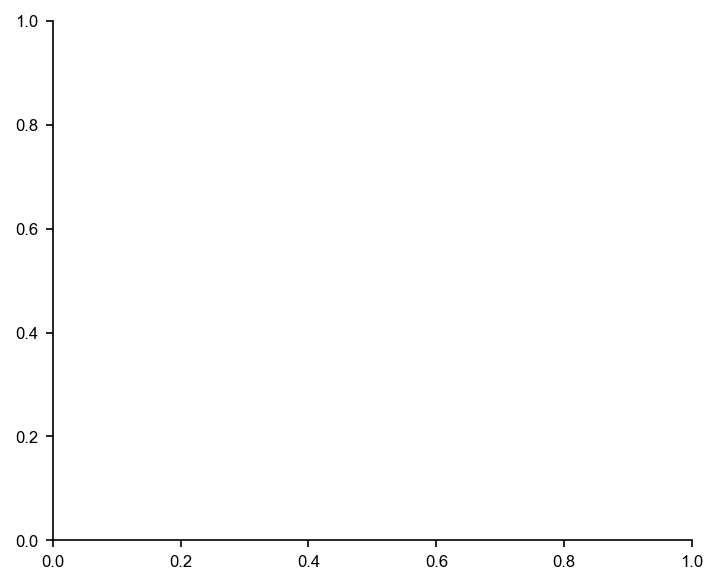

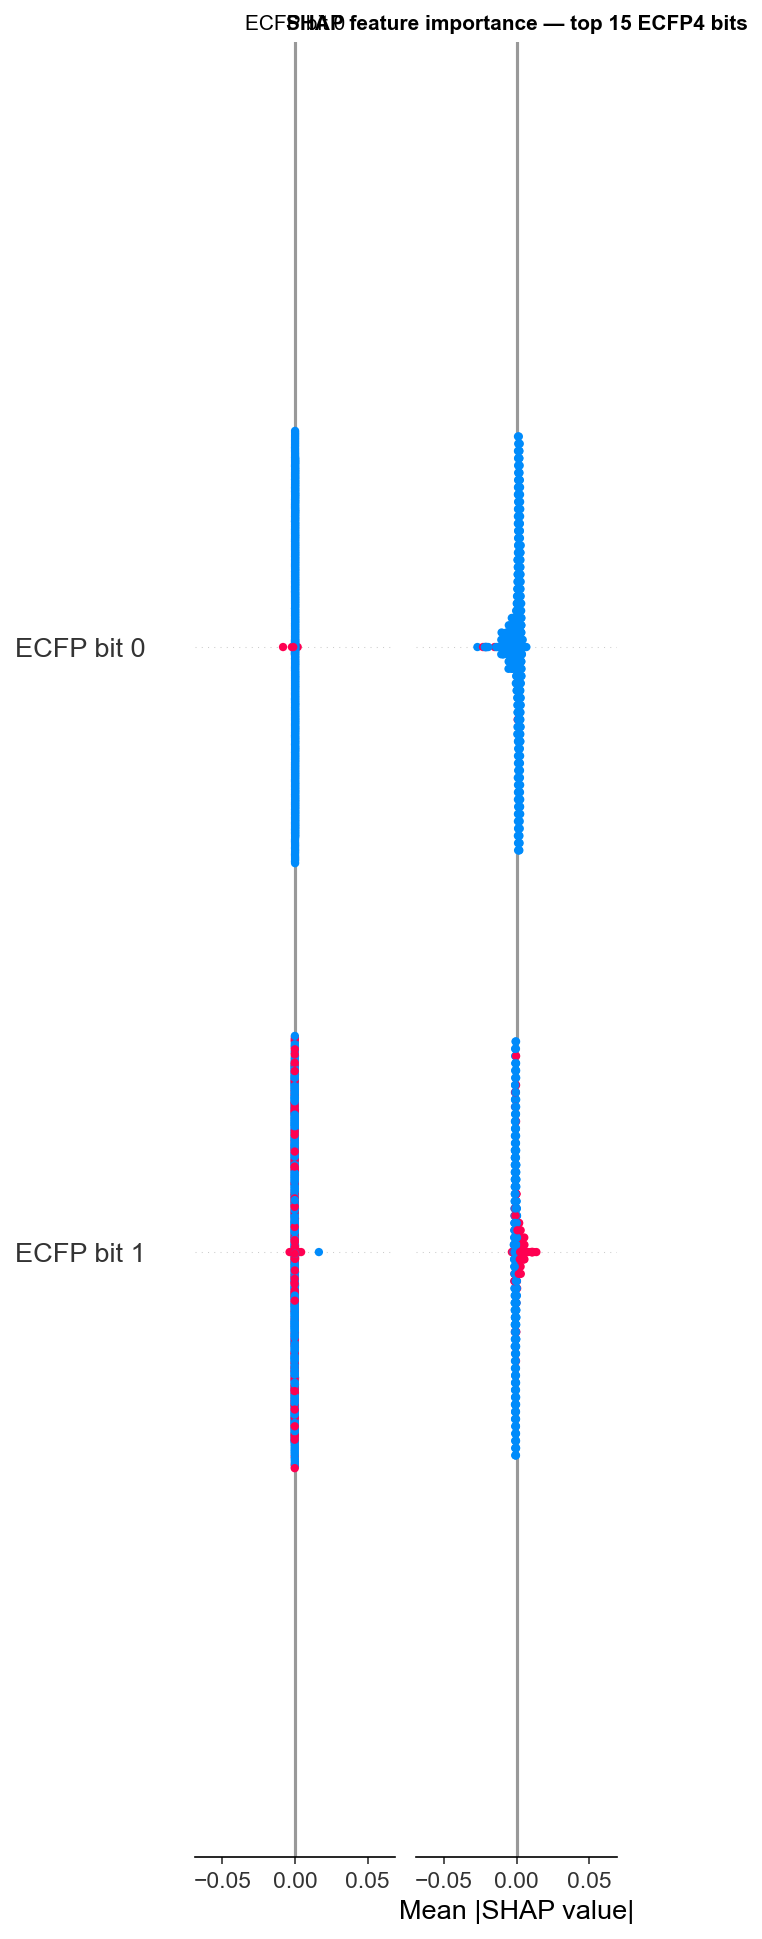

In [8]:
import shap

print("Computing SHAP values...")
background = shap.sample(X_train, 500, random_state=SEED)
explainer  = shap.TreeExplainer(rf, background)
X_explain  = X_test[:500]
shap_vals  = explainer.shap_values(X_explain)
sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

fig, ax = plt.subplots(figsize=(5.5, 4.5))
shap.summary_plot(sv, X_explain,
                  feature_names=[f"ECFP bit {i}" for i in range(X_train.shape[1])],
                  max_display=15, show=False, plot_size=None)
ax = plt.gca()
ax.set_title('SHAP feature importance — top 15 ECFP4 bits', fontweight='bold', fontsize=10)
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
save_fig(plt.gcf(), 'fig5_shap')
plt.show()

## Figure 6 — Training dynamics

In [9]:
# Training curves are logged in the modeling notebook.
# Here we re-plot from saved checkpoint log if available, otherwise skip.
TRAINER_LOG = CKPT_DIR / 'chembert' / 'checkpoint-21492' / 'trainer_state.json'

if TRAINER_LOG.exists():
    with open(TRAINER_LOG) as f:
        state = json.load(f)
    history = state.get('log_history', [])
    train_loss = [(h['step'], h['loss'])      for h in history if 'loss'      in h]
    eval_loss  = [(h['step'], h['eval_loss']) for h in history if 'eval_loss' in h]

    fig, ax = plt.subplots(figsize=(4.5, 3))
    if train_loss:
        steps, vals = zip(*train_loss)
        ax.plot(steps, vals, color=C['mlp'],  lw=1.2, label='Training loss')
    if eval_loss:
        steps, vals = zip(*eval_loss)
        ax.plot(steps, vals, color=C['rf'], lw=1.2, ls='--', marker='o', ms=3, label='Validation loss')
    ax.set(xlabel='Steps', ylabel='Loss', title='ChemBERTa fine-tuning loss')
    ax.legend(frameon=False)
    plt.tight_layout()
    save_fig(fig, 'fig6_chemberta_loss')
    plt.show()
else:
    print("ChemBERTa trainer log not found — skipping Figure 6.")
    print(f"Expected: {TRAINER_LOG}")

NameError: name 'json' is not defined

## Supplementary — Model comparison table

           Model  ROC-AUC  PRC-AUC       Features     Params
   Random Forest   0.9162   0.8917 ECFP4 2048-bit ~300 trees
Deep MLP (ECFP4)   0.9131   0.8891 ECFP4 2048-bit      ~1.6M
Saved: figS1_model_comparison.png / .svg


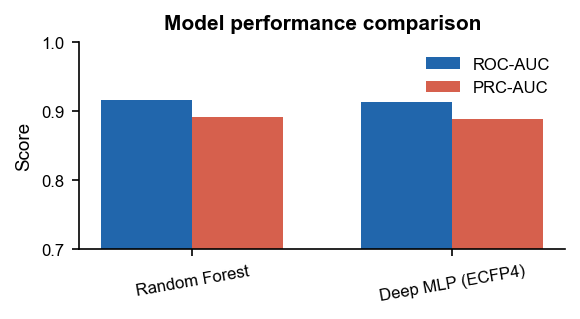

In [10]:
import json as _json

comparison = pd.DataFrame({
    'Model':   ['Random Forest', 'Deep MLP (ECFP4)'],
    'ROC-AUC': [round(rf_roc,  4), round(mlp_roc, 4)],
    'PRC-AUC': [round(rf_prc,  4), round(mlp_prc, 4)],
    'Features':['ECFP4 2048-bit', 'ECFP4 2048-bit'],
    'Params':  ['~300 trees', '~1.6M'],
})
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(4, 2.2))
df_m = comparison.melt(id_vars='Model', value_vars=['ROC-AUC','PRC-AUC'],
                        var_name='Metric', value_name='Score')
x    = np.arange(len(comparison))
w    = 0.35
roc_vals = comparison['ROC-AUC'].values
prc_vals = comparison['PRC-AUC'].values
ax.bar(x - w/2, roc_vals, w, color=C['active'],   label='ROC-AUC', edgecolor='none')
ax.bar(x + w/2, prc_vals, w, color=C['ensemble'], label='PRC-AUC', edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'], rotation=10)
ax.set_ylim(0.7, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model performance comparison', fontweight='bold')
ax.legend(frameon=False)
plt.tight_layout()
save_fig(fig, 'figS1_model_comparison')
plt.show()